In [48]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
import scipy.special as sc

In [49]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][1]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [3]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2810/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2810/553640031.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2810/553640031.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [75]:
def NormGuassianStepPoly(x,mu,sigma,f, p1, p2, d, E0, E1):
    Ec = (E1+E0)/2
    DE = (E1-E0)/2
    
    norm_poly = 2*DE+(2/3)*p2*DE**3
    poly = (1+p1*(x-Ec)+p2*(x-Ec)**2)/norm_poly
    
    step_norm_const = ((mu-E0)*special.erfc((E0-mu)/np.sqrt(2*np.pi*sigma**2))+(E1-mu)*special.erfc((E1-mu)/np.sqrt(2*np.pi*sigma**2))+np.sqrt(2*sigma**2)*(np.exp(-(mu-E0)**2/(2*np.pi*sigma**2))-np.exp(-(mu-E1)**2/(2*np.pi*sigma**2))))
    return (1-f-d)*(np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2)+f*poly+(d*special.erfc((x-mu)/np.sqrt(2*np.pi*sigma**2)))/step_norm_const

def NegLogLikelihoodGuassStepPoly(params,data):
    mu,sigma, f, p1,p2, d = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianStepPoly(data,mu,sigma,f, p1,p2, d, E0, E1)
    x = x[x > 0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLikelihoodGuassStepPoly(data, initial_params):
    result = minimize(NegLogLikelihoodGuassStepPoly, initial_params, args=(data),
                      method='Nelder-Mead',bounds=[(0, None), (0, None), (0,1),  (None, None), (None, None), (0,1)])
    return result.x

def Chi2(data, arr):
    mu_fit, sigma_fit,f_fit,p1_fit, p2_fit, d_fit = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianStepPoly(filtered_bin_centers,mu_fit, sigma_fit,f_fit,p1_fit, p2_fit, d_fit ,E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    mu_fit, sigma_fit, f_fit, p1_fit, p2_fit, d_fit = arr
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    x_values = np.linspace(min(data), max(data), 1000)
    fitted_pdf = NormGuassianStepPoly(x_values, mu_fit, sigma_fit, f_fit, p1_fit,p2_fit, d_fit, min(x_values), max(x_values))*len(data)*bin_width
    
    guass = (1-f_fit-d_fit)*(np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2)*len(data)*bin_width
    quad_bkg = (f_fit*((1+p1_fit*(x_values-(max(data)+min(data))/2)+p2_fit*(x_values-(max(data)+min(data))/2)**2)/(2*(max(data)-min(data))/2+(2/3)*p2_fit*((max(data)-min(data))/2)**3)))*len(data)*bin_width
    step = ((d_fit*special.erfc((x_values-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2)))/((mu_fit-min(data))*special.erfc((min(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+(max(data)-mu_fit)*special.erfc((max(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+np.sqrt(2*sigma_fit**2)*(np.exp(-(mu_fit-min(data))**2/(2*np.pi*sigma_fit**2))-np.exp(-(mu_fit-max(data))**2/(2*np.pi*sigma_fit**2)))))*len(data)*bin_width
    
    return x_values, fitted_pdf, guass, quad_bkg, step

def Residual_Plot(data, arr):
    mu,sigma,f, p1, p2, d = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianStepPoly(filtered_bin_centers, mu, sigma, f, p1,p2, d, min(data), max(data))*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)



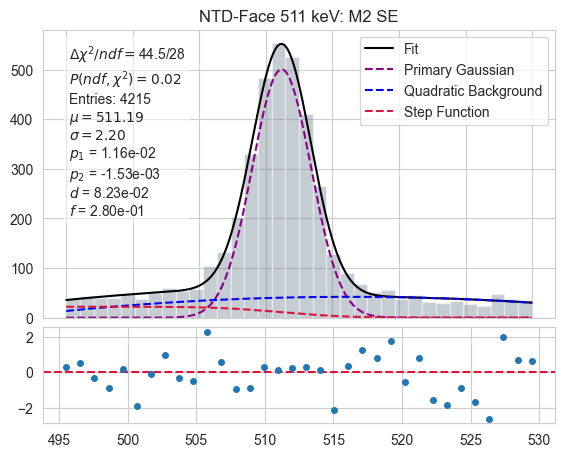

In [82]:
data = [i for i in NTD_511 if 495 <= i <= 530]

initial_parms = [5.11206318e+02,  2.20254997e+00,  0.3, 0, -1e-5, 0.1]
data_fits = MinimizeNegLogLikelihoodGuassStepPoly(data, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
bin_num = int(max(data) - min(data))
bin_width = (max(data) - min(data))/bin_num

x_values, fitted_pdf, guass, quad, step = Graph(data, data_fits)

chisq = Chi2(data, data_fits)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(chisq, decimals=2)) +'/' +str(int(max(data) - min(data)) - 6, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(data) - min(data)) - 6, chisq), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (data_fits[0], ),
    r'$\sigma=%.2f$' % (data_fits[1], ),
    r'$p_1$ = ' + str(np.format_float_scientific(data_fits[3], precision = 2), ),
    r'$p_2$ = ' + str(np.format_float_scientific(data_fits[4], precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(data_fits[5], precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(data_fits[2], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.plot(x_values, guass, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, quad, label = 'Quadratic Background', linestyle='--', color='blue')
ax.plot(x_values, step, label='Step Function', linestyle = '--', color='crimson')

ax.hist(data, bins = bin_num , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 511 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(data, data_fits)[0],Residual_Plot(data, data_fits)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

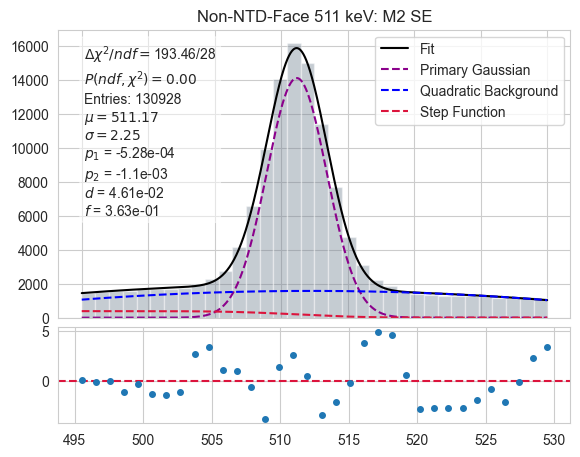

In [83]:
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

dataNoNTD = [i for i in noNTD_511 if 495 <= i <= 530]

initial_parms = [511.1795759540014,  2.297221891188979,  0.4033494600536791, -0.00045670951328829026, -0.0005578241091289861, 0.06412653780753474]
noNTDfits = MinimizeNegLogLikelihoodGuassStepPoly(dataNoNTD, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
bin_num = int(max(dataNoNTD) - min(dataNoNTD))
bin_width = (max(dataNoNTD) - min(dataNoNTD))/bin_num

x_values, fitted_pdf, guass, quad, step = Graph(dataNoNTD, noNTDfits)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf=$'+ str(np.round(Chi2(dataNoNTD, noNTDfits), decimals=2)) +'/' +str(int(max(dataNoNTD) - min(dataNoNTD)) - 6, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(43, Chi2(dataNoNTD, noNTDfits))),
    'Entries: ' + (str(len(dataNoNTD))),
    r'$\mu=%.2f$' % (noNTDfits[0], ),
    r'$\sigma=%.2f$' % (noNTDfits[1], ),
    r'$p_1$ = ' + str(np.format_float_scientific(noNTDfits[3], precision = 2), ),
    r'$p_2$ = ' + str(np.format_float_scientific(noNTDfits[4], precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(noNTDfits[5], precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(noNTDfits[2], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.plot(x_values, guass, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, quad, label = 'Quadratic Background', linestyle='--', color='blue')
ax.plot(x_values, step, label='Step Function', linestyle = '--', color='crimson')

ax.hist(dataNoNTD, bins = int(max(dataNoNTD)- min(dataNoNTD)) , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 511 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(dataNoNTD, noNTDfits)[0],Residual_Plot(dataNoNTD, noNTDfits)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

In [84]:
F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

F_511_cut = [i for i in F_511 if 495 <= i <= 530]
C_511_cut = [i for i in C_511 if 495 <= i <= 530]
N_511_cut = [i for i in N_511 if 495 <= i <= 530]
E_511_cut = [i for i in E_511 if 495 <= i <= 530]

In [85]:
F_initial_511= [5.11214209e+02,  2.39241791e+00,  0.395660371031462, 0.006635850309094038, -2.7279620703405247e-05, 0.1]
C_initial_511 = [5.11142240e+02,  2.18732146e+00,  0.395660371031462, 0.006635850309094038, -2.7279620703405247e-05, 0.1]
N_initial_511 = [5.11125800e+02,  2.18277950e+00,  0.395660371031462, 0.006635850309094038, -2.7279620703405247e-05, 0.1]
E_initial_511 = [5.11073460e+02,  2.15571423e+00,  0.395660371031462, 0.006635850309094038, -2.7279620703405247e-05, 0.1]

Carr = MinimizeNegLogLikelihoodGuassStepPoly(C_511_cut, C_initial_511)
Earr = MinimizeNegLogLikelihoodGuassStepPoly(E_511_cut, E_initial_511)
Narr = MinimizeNegLogLikelihoodGuassStepPoly(N_511_cut, N_initial_511)
Farr = MinimizeNegLogLikelihoodGuassStepPoly(F_511_cut, F_initial_511)

In [86]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def TopologyPlots(hist_data, initial_parms, topologies):
    bin_num = []
    xvals = []
    chi2s = []
    fitvals = []
    guassvals = []
    quadvals = []
    stepvals = []
    
    for i in range(len(hist_data)):
        x, PDF_fit, guass, quad, step = Graph(hist_data[i], initial_parms[i])
        bin_num.append(int(max(hist_data[i])-min(hist_data[i])))
        xvals.append(x)
        fitvals.append(PDF_fit)
        quadvals.append(quad)
        stepvals.append(step)
        guassvals.append(guass)
        
        chi2s.append(Chi2(hist_data[i], initial_parms[i]))
    
    pvals = []
    
    for j in chi2s:
        pvals.append(PValue(43,j))
    
    means = []
    sigmas = []
    ds =[]
    p1s = []
    p2s = []
    fs = []
    
    for i in range(len(initial_parms)):
        means.append(initial_parms[i][0])
        sigmas.append(initial_parms[i][1])
        p1s.append(initial_parms[i][3])
        p2s.append(initial_parms[i][4])
        ds.append(initial_parms[i][5])
        fs.append(initial_parms[i][2])
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': hist_data,
        'X-axis': xvals,
        'Fit': fitvals,
        'Quad': quadvals,
        'Guass': guassvals,
        'Step': stepvals,
        'Means': means,
        'Sigmas': sigmas,
        'p1s': p1s,
        'p2s': p2s, 
        'd': ds,
        'f': fs, 
        'Chi2': chi2s,
        'p-value': pvals}
    
    df = pd.DataFrame(data)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    props = dict(boxstyle='round', facecolor='whitesmoke')

    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) + '/' + str(df['Bin Num'][i] - 6, ),
            r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
            'Entries: ' + (str(len(df['Histogram Data'][i]))),
            r'$\mu=%.2f$' % (df['Means'][i], ),
            r'$\sigma=%.2f$' % (df['Sigmas'][i], ),
            r'$p_1$ = ' + str(np.format_float_scientific(df['p1s'][i], precision = 2), ),
            r'$p_2$ = ' + str(np.format_float_scientific(df['p2s'][i], precision = 2), ),
            r'$d$ = ' + str(np.format_float_scientific(df['d'][i], precision = 2), ),
            r'$f$ = ' + str(np.format_float_scientific(df['f'][i], precision = 2), )))
            
            ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], color='slategray', alpha=0.4)
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='black')
            ax.plot(df['X-axis'][i], df['Quad'][i], label='Quadratic Background', linestyle='--', color='purple')
            ax.plot(df['X-axis'][i], df['Step'][i], label='Step Function', linestyle='--', color='crimson')
            ax.plot(df['X-axis'][i], df['Guass'][i], label='Gaussian', linestyle='--', color='blue')
            ax.set_title(df["Topologies"][i])
            ax.legend()
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(hist_data[i], initial_parms[i])[0],Residual_Plot(hist_data[i], initial_parms[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()

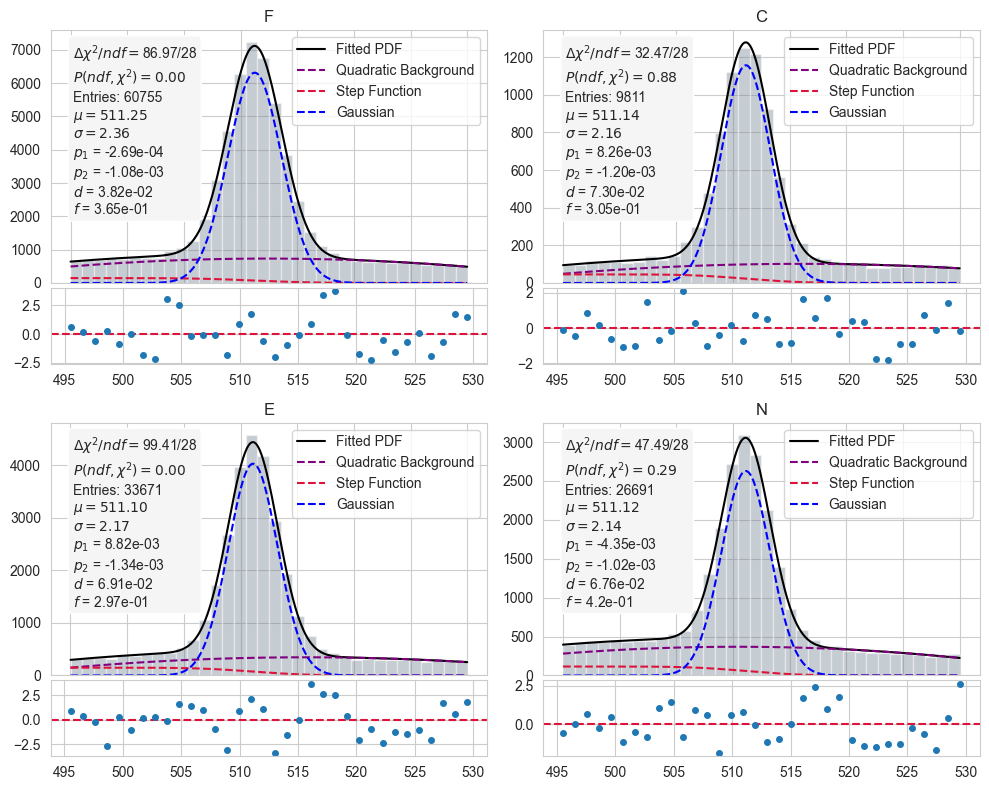

In [87]:
hist_data = [F_511_cut, C_511_cut, E_511_cut, N_511_cut]
initial_parms = [Farr, Carr, Earr, Narr]
topologies = ['F', 'C', 'E', 'N']

TopologyPlots(hist_data, initial_parms, topologies)

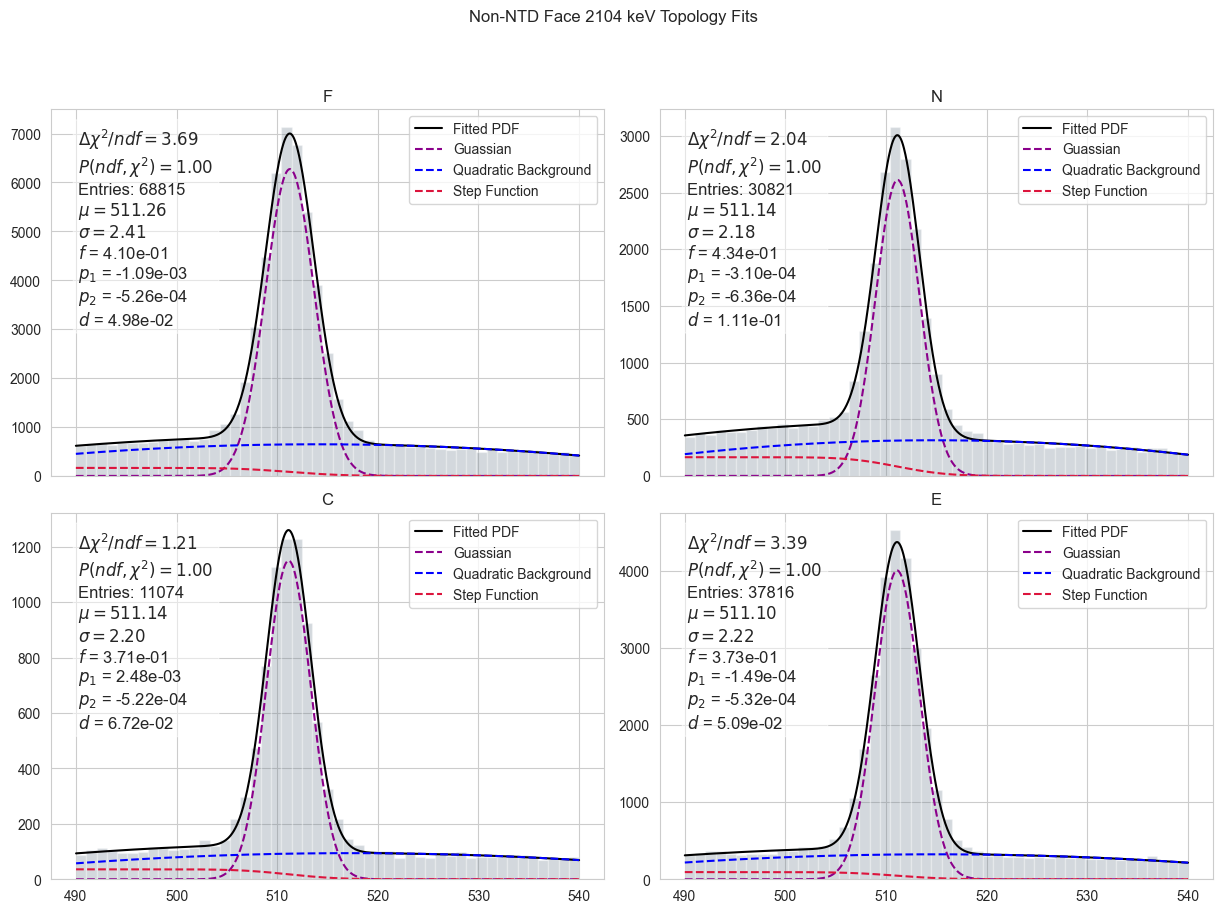

In [12]:
fig, ax = plt.subplots(2,2, sharex='col', figsize=(15, 10))
# fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('Non-NTD Face 2104 keV Topology Fits')
plt.subplots_adjust(wspace=0.1, hspace=0.1)

textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Fchi2/(int(max(F_511_cut) - min(F_511_cut)) - 6), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (sc.gammainc(6/2, Fchi2/2), ),       
    'Entries: ' + (str(len(F_511_cut))),
    r'$\mu=%.2f$' % (Fmu_fit, ),
    r'$\sigma=%.2f$' % (Fsigma_fit, ),
    r'$f$ = ' + str(np.format_float_scientific(Ff_fit, precision = 2), ),
r'$p_1$ = ' + str(np.format_float_scientific(Fp1_fit, precision = 2), ),
r'$p_2$ = ' + str(np.format_float_scientific(Fp2_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Fd_fit, precision = 2))))

ax[0,0].plot(Fx, F_fit, color='black', label='Fitted PDF')
ax[0,0].plot(Fx, Fguass, color='darkmagenta', label='Guassian', linestyle='--')
ax[0,0].plot(Fx, Fquad, color='blue', label='Quadratic Background', linestyle='--')
ax[0,0].plot(Fx, Fstep,label='Step Function', color='crimson', linestyle='--')


ax[0,0].hist(F_511_cut, bins = int(max(F_511_cut) - min(F_511_cut)) , color='slategrey', alpha=0.3)
ax[0,0].text(0.05, 0.95, textF, transform=ax[0,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('F')
ax[0,0].legend()

###########

textC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Cchi2/(int(max(C_511_cut) - min(C_511_cut))-6), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (sc.gammainc(6/2, Cchi2/2), ),  
    'Entries: ' + (str(len(C_511_cut))),
    r'$\mu=%.2f$' % (Cmu_fit, ),
    r'$\sigma=%.2f$' % (Csigma_fit, ),
    r'$f$ = ' + str(np.format_float_scientific(Cf_fit, precision = 2), ),
r'$p_1$ = ' + str(np.format_float_scientific(Cp1_fit, precision = 2), ),
r'$p_2$ = ' + str(np.format_float_scientific(Cp2_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Cd_fit, precision = 2))))

ax[1,0].plot(Cx, C_fit,label='Fitted PDF', color='black')
ax[1,0].plot(Cx, Cguass, color='darkmagenta', label='Guassian', linestyle='--')
ax[1,0].plot(Cx, Cquad, color='blue', label='Quadratic Background', linestyle='--')
ax[1,0].plot(Cx, Cstep,label='Step Function', color='crimson', linestyle='--')

ax[1,0].hist(C_511_cut, bins = int(max(C_511_cut) - min(C_511_cut)) , color='slategrey', alpha=0.3)
ax[1,0].text(0.05, 0.95, textC, transform=ax[1,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('C')
ax[1,0].legend()
#########

textN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Nchi2/(int(max(N_511_cut) - min(N_511_cut))-6), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (sc.gammainc(6/2, Nchi2/2), ),  
    'Entries: ' + (str(len(N_511_cut))),
    r'$\mu=%.2f$' % (Nmu_fit, ),
    r'$\sigma=%.2f$' % (Nsigma_fit, ),
    r'$f$ = ' + str(np.format_float_scientific(Nf_fit, precision = 2), ),
r'$p_1$ = ' + str(np.format_float_scientific(Np1_fit, precision = 2), ),
r'$p_2$ = ' + str(np.format_float_scientific(Np2_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Nd_fit, precision = 2))))

ax[0,1].plot(Nx, N_fit,label='Fitted PDF', color='black')
ax[0,1].plot(Nx, Nguass, color='darkmagenta', label='Guassian', linestyle='--')
ax[0,1].plot(Nx, Nquad, color='blue', label='Quadratic Background', linestyle='--')
ax[0,1].plot(Nx, Nstep,label='Step Function', color='crimson', linestyle='--')


ax[0,1].hist(N_511_cut, bins = int(max(N_511_cut) - min(N_511_cut)) , color='slategrey', alpha=0.3)
ax[0,1].text(0.05, 0.95, textN, transform=ax[0,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('N')
ax[0,1].legend()
########

textE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Echi2/(int(max(E_511_cut) - min(E_511_cut))-6), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (sc.gammainc(6/2, Echi2/2), ),  
    'Entries: ' + (str(len(E_511_cut))),
    r'$\mu=%.2f$' % (Emu_fit, ),
    r'$\sigma=%.2f$' % (Esigma_fit, ),
    r'$f$ = ' + str(np.format_float_scientific(Ef_fit, precision = 2), ),
r'$p_1$ = ' + str(np.format_float_scientific(Ep1_fit, precision = 2), ),
r'$p_2$ = ' + str(np.format_float_scientific(Ep2_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Ed_fit, precision = 2))))

ax[1,1].plot(Ex, E_fit,label='Fitted PDF', color='black')
ax[1,1].plot(Ex, Eguass, color='darkmagenta', label='Guassian', linestyle='--')
ax[1,1].plot(Ex, Equad, color='blue', label='Quadratic Background', linestyle='--')
ax[1,1].plot(Ex, Estep,label='Step Function', color='crimson', linestyle='--')

ax[1,1].hist(E_511_cut, bins = int(max(E_511_cut) - min(E_511_cut)) , color='slategrey', alpha=0.3)
ax[1,1].text(0.05, 0.95, textE, transform=ax[1,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('E')
ax[1,1].legend()

In [17]:
def NegLogLikelihoodGuassLinear(params,data):
    mu,sigma, f, p1,p2, d = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianStepPoly(k,mu,sigma,f, p1, p2,d, E0, E1)
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma,f, p1,p2,d):
    params = [mu, sigma, f, p1, p2,d]
    arr1 = NegLogLikelihoodGuassLinear(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.05))[0]
            intersection = mu[intersection_indices]
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.5))[0]
            intersection = sigma[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [18]:
Fmu_arr = np.linspace(Fmu_fit-1, Fmu_fit+5, 1000)
Cmu_arr = np.linspace(Cmu_fit-5, Cmu_fit+5, 100)
Nmu_arr = np.linspace(Nmu_fit-5, Nmu_fit+5, 100)
Emu_arr = np.linspace(Emu_fit-5, Emu_fit+5, 100)

Fintersection_mu, Ferror_mu = Uncertainity(F_511_cut, Fmu_arr, Fsigma_fit,Ff_fit,Fp1_fit, Fp2_fit, Fd_fit)
Cintersection_mu, Cerror_mu = Uncertainity(C_511_cut, Cmu_arr, Csigma_fit,Cf_fit,Cp1_fit, Cp2_fit, Cd_fit)
Nintersection_mu, Nerror_mu = Uncertainity(N_511_cut, Nmu_arr, Nsigma_fit,Nf_fit,Np1_fit, Np2_fit, Nd_fit)
Eintersection_mu, Eerror_mu = Uncertainity(E_511_cut, Emu_arr, Esigma_fit,Ef_fit,Ep1_fit, Ep2_fit, Ed_fit)

Fsigma_arr = np.linspace(Fsigma_fit/2, Fsigma_fit*2, 1000)
Csigma_arr = np.linspace(Csigma_fit/2, Csigma_fit*2, 1000)
Esigma_arr = np.linspace(Esigma_fit/1.5, Esigma_fit*1.5, 1000)
Nsigma_arr = np.linspace(Nsigma_fit/1.5, Nsigma_fit*1.5, 1000)

Fintersection_sigma, Ferror_sigma = Uncertainity(F_511_cut, Fmu_fit, Fsigma_arr,Ff_fit,Fp1_fit, Fp2_fit, Fd_fit)
Cintersection_sigma, Cerror_sigma = Uncertainity(C_511_cut, Cmu_fit, Csigma_arr,Cf_fit,Cp1_fit, Cp2_fit, Cd_fit)
Nintersection_sigma, Nerror_sigma = Uncertainity(N_511_cut, Nmu_fit, Nsigma_arr,Nf_fit,Np1_fit, Np2_fit, Nd_fit)
Eintersection_sigma, Eerror_sigma = Uncertainity(E_511_cut, Emu_fit, Esigma_arr,Ef_fit,Ep1_fit, Ep2_fit, Ed_fit)

In [19]:
mu_arr = np.linspace(mu_fit-2, mu_fit+2, 1000)
intersection_mu, error_mu = Uncertainity(data, mu_arr, sigma_fit,f_fit,p1_fit, p2_fit, d_fit)
noNTDmu_arr = np.linspace(noNTDmu_fit-5, noNTDmu_fit+5, 3000)
noNTDintersection_mu, noNTDerror_mu = Uncertainity(dataNoNTD, noNTDmu_arr, noNTDsigma_fit, noNTDf_fit, noNTDp1_fit, noNTDp2_fit, noNTDd_fit)

sigma_arr = np.linspace(sigma_fit/1.5, sigma_fit*1.5, 100)
intersection_sigma, error_sigma = Uncertainity(data, mu_fit, sigma_arr,f_fit,p1_fit, p2_fit, d_fit)
noNTDsigma_arr = np.linspace(noNTDsigma_fit/1.5, noNTDsigma_fit*1.5, 1000)
noNTDintersection_sigma, noNTDerror_sigma = Uncertainity(dataNoNTD, noNTDmu_fit, noNTDsigma_arr,noNTDf_fit,noNTDp1_fit,noNTDp2_fit ,noNTDd_fit)

Text(0.5, 1.0, 'M2 Single Escape: 511 keV Means')

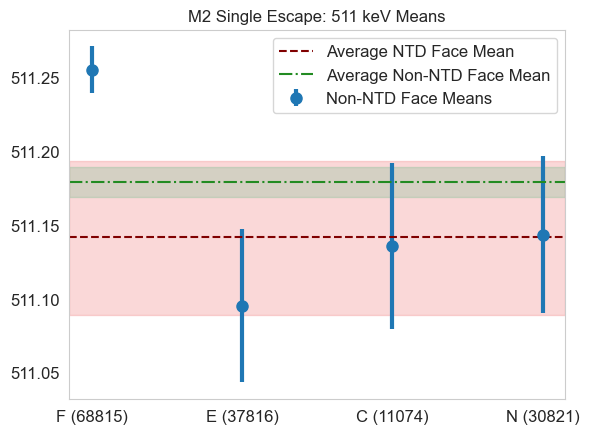

In [20]:
ax = plt.subplot()

topologies = ['F' + ' (' + (str(len(F_511_cut))) + ')', 'E' + ' ('+ (str(len(E_511_cut))) + ')', "C" + ' ('+ (str(len(C_511_cut))) +')', 'N'+ ' ('+ (str(len(N_511_cut))) + ')']
means = [Fmu_fit, Emu_fit, Cmu_fit, Nmu_fit]
mu_intersections = [[Fintersection_mu.geoms[0].x, Fintersection_mu.geoms[1].x],[Eintersection_mu.geoms[0].x, Eintersection_mu.geoms[1].x],
                   [Cintersection_mu.geoms[0].x, Cintersection_mu.geoms[1].x], [Nintersection_mu.geoms[0].x,Nintersection_mu.geoms[1].x] ]

asymmetric_errormu = Errors(mu_intersections, means)

ax.errorbar(topologies, means, yerr=asymmetric_errormu, fmt='o', ms = 8, elinewidth=3, label='Non-NTD Face Means')
ax.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')
ax.axhspan(noNTDintersection_mu.geoms[0].x, noNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(noNTDmu_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

ax.grid(False)
ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single Escape: 511 keV Means')

Text(0.5, 1.0, 'M2 Single: 511 Standard Dev')

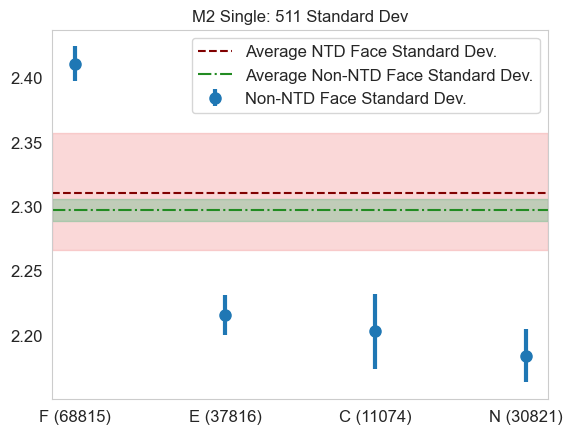

In [21]:
ax = plt.subplot()

topologies = ['F' + ' (' + (str(len(F_511_cut))) + ')', 'E' + ' ('+ (str(len(E_511_cut))) + ')', "C" + ' ('+ (str(len(C_511_cut))) +')', 'N'+ ' ('+ (str(len(N_511_cut))) + ')']
sds = [Fsigma_fit, Esigma_fit, Csigma_fit, Nsigma_fit]

sds_intersections = [[Fintersection_sigma.geoms[0].x, Fintersection_sigma.geoms[1].x],[Eintersection_sigma.geoms[0].x, Eintersection_sigma.geoms[1].x],
                   [Cintersection_sigma.geoms[0].x, Cintersection_sigma.geoms[1].x], [Nintersection_sigma.geoms[0].x,Nintersection_sigma.geoms[1].x] ]

asymmetric_error = Errors(sds_intersections, sds)

ax.errorbar(topologies, sds, yerr=asymmetric_error, fmt='o', ms=8, elinewidth=3, label='Non-NTD Face Standard Dev.')
ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Standard Dev.')

ax.axhspan(noNTDintersection_sigma.geoms[0].x, noNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.3)
ax.axhline(noNTDsigma_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev.')

ax.legend(fontsize=12)
ax.grid(False)
plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single: 511 Standard Dev')

In [106]:
for i in range(len(means)):
    print(str(means[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

print(noNTDmu_fit)
print(noNTDmu_fit - noNTDintersection_mu.geoms[0].x)
print(noNTDmu_fit - noNTDintersection_mu.geoms[1].x)

511.25519333364196-0.015618267083539195+0.015877310872610906
511.0955718408609-0.05214953408795964+0.052147245643823226
511.1359753804204-0.056225501339042694+0.05621053395873332
511.14346103242997-0.05327137981936403+0.053317689680966396
511.1422713538383
0.05313723809678095
-0.05154371829110005
511.1795759540014
0.010198472497620514
-0.010144286248817025


In [107]:
for i in range(len(sds)):
    print(str(sds[i]) + '+' + str(asymmetric_error[0][i]) + '-' + str(asymmetric_error[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(noNTDsigma_fit)
print(noNTDsigma_fit - noNTDintersection_sigma.geoms[0].x)
print(noNTDsigma_fit - noNTDintersection_sigma.geoms[1].x)

2.41089323392318+0.013448853089613522-0.013399049812491626
2.2156729007798326+0.01562116663895674-0.01573661475405075
2.202890251311204+0.028909711224309742-0.029378695902003482
2.1838595721531653+0.02070092761613873-0.020956196853977538
2.310355478219989
-0.04704873856308289
0.04440274759188423
2.297221891188979
0.008807863860432086
-0.00886366297830099
